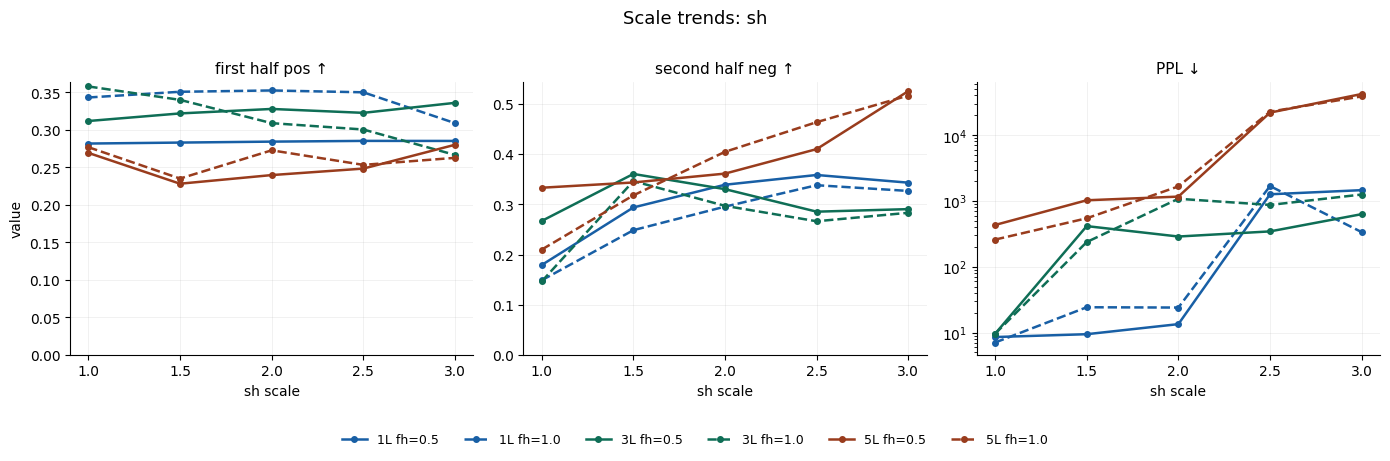

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("results_ranked.csv")

# --- Aggregate ---
# SH trend: avg over alphas, per (layer_count, first_half_scale, second_half_scale)
sh_trend = df.groupby(["layer_count", "first_half_scale", "second_half_scale"]).agg(
    fh_pos=("first_half_positive", "mean"),
    sh_neg=("second_half_negative", "mean"),
    ppl=("second_half_perplexity", "mean"),
).reset_index()

LAYERS = [1, 3, 5]
COLORS = {1: "#185FA5", 3: "#0F6E56", 5: "#993C1D"}
FH_STYLES = {0.5: "-", 1.0: "--"}
METRICS = ["fh_pos", "sh_neg", "ppl"]
METRIC_LABELS = ["first half pos ↑", "second half neg ↑", "PPL ↓"]

SH_VALS = [1.0, 1.5, 2.0, 2.5, 3.0]
FH_VALS = [0.5, 1.0]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Scale trends: sh", fontsize=13, y=1.01)

# ── Only Top row: SH trend (x = sh_scale, hue = layer, style = fh_scale) ──
for col, (metric, mlabel) in enumerate(zip(METRICS, METRIC_LABELS)):
    ax = axes[col]
    for lc in LAYERS:
        for fhs in FH_VALS:
            sub = sh_trend[(sh_trend.layer_count == lc) & (sh_trend.first_half_scale == fhs)]
            sub = sub.sort_values("second_half_scale")
            y = sub[metric].values
            x = sub["second_half_scale"].values
            if metric == "ppl":
                mask = ~np.isnan(y) & (y > 0)
                ax.semilogy(x[mask], y[mask],
                            color=COLORS[lc], linestyle=FH_STYLES[fhs],
                            linewidth=1.8, marker="o", markersize=4,
                            label=f"{lc}L fh={fhs}")
            else:
                ax.plot(x, y,
                        color=COLORS[lc], linestyle=FH_STYLES[fhs],
                        linewidth=1.8, marker="o", markersize=4,
                        label=f"{lc}L fh={fhs}")
    ax.set_title(mlabel, fontsize=11)
    ax.set_xlabel("sh scale", fontsize=10)
    ax.set_xticks(SH_VALS)
    ax.grid(True, alpha=0.25, linewidth=0.5)
    ax.spines[["top", "right"]].set_visible(False)
    if metric != "ppl":
        ax.set_ylim(bottom=0)
    if col == 0:
        ax.set_ylabel("value", fontsize=10)

# ── Shared legend ──
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="lower center", ncol=6,
           fontsize=9, frameon=False,
           bbox_to_anchor=(0.5, -0.11))

plt.tight_layout()
plt.savefig("scale_trends.png", dpi=150, bbox_inches="tight")
plt.show()